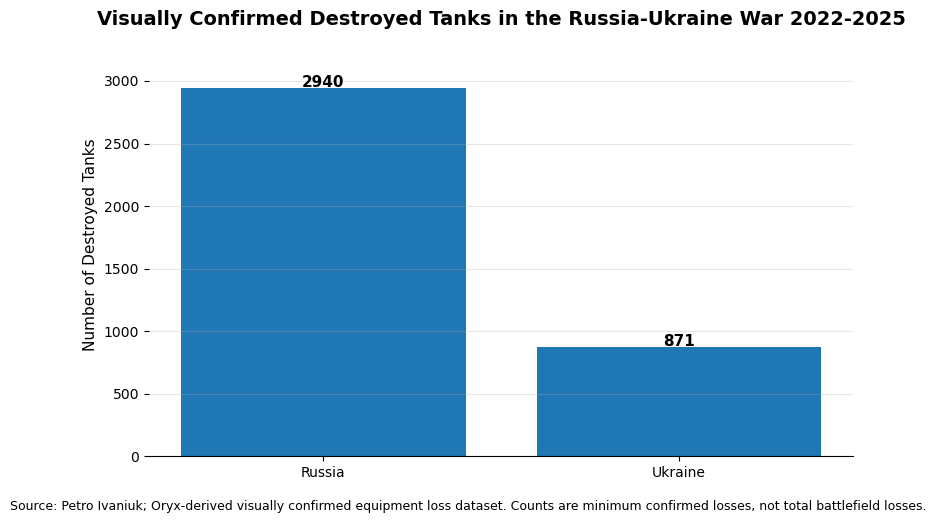

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

ukr = pd.read_csv("data/losses_ukraine.csv")
rus = pd.read_csv("data/losses_russia.csv")

rus.head()
ukr.head()

rus_tanks = rus[rus["equipment"] == "Tanks"].copy()
ukr_tanks = ukr[ukr["equipment"] == "Tanks"].copy()

info_cols = ["equipment", "model", "sub_model", "manufacturer", "losses_total"]

rus_loss_cols = [col for col in rus.columns if col not in info_cols]
ukr_loss_cols = [col for col in ukr.columns if col not in info_cols]

loss_type_cols = [col for col in rus_loss_cols if col in ukr_loss_cols]

rus_tanks[loss_type_cols] = rus_tanks[loss_type_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
ukr_tanks[loss_type_cols] = ukr_tanks[loss_type_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

rus_destroyed = rus_tanks["destroyed"].sum()
ukr_destroyed = ukr_tanks["destroyed"].sum()

countries = ["Russia", "Ukraine"]
destroyed_counts = [rus_destroyed, ukr_destroyed]

plt.figure(figsize=(8, 5))

bars = plt.bar(countries, destroyed_counts)

plt.title("Visually Confirmed Destroyed Tanks in the Russia-Ukraine War 2022-2025", fontsize=14, fontweight="bold")
plt.ylabel("Number of Destroyed Tanks", fontsize=11)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        int(height),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.ylim(0, max(destroyed_counts) * 1.15)

plt.figtext(
    0.5,
    -0.03,
    "Source: Petro Ivaniuk; Oryx-derived visually confirmed equipment loss dataset. Counts are minimum confirmed losses, not total battlefield losses.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()




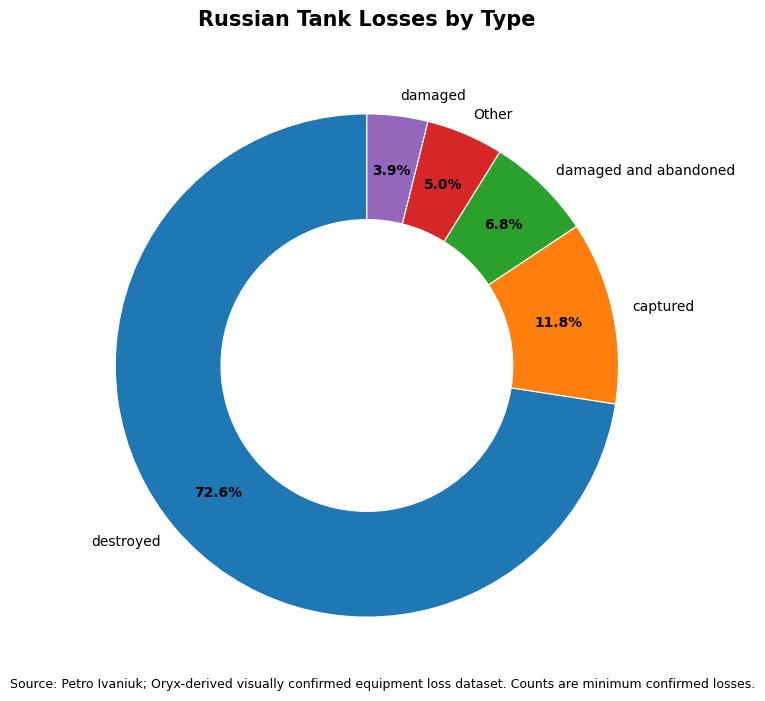

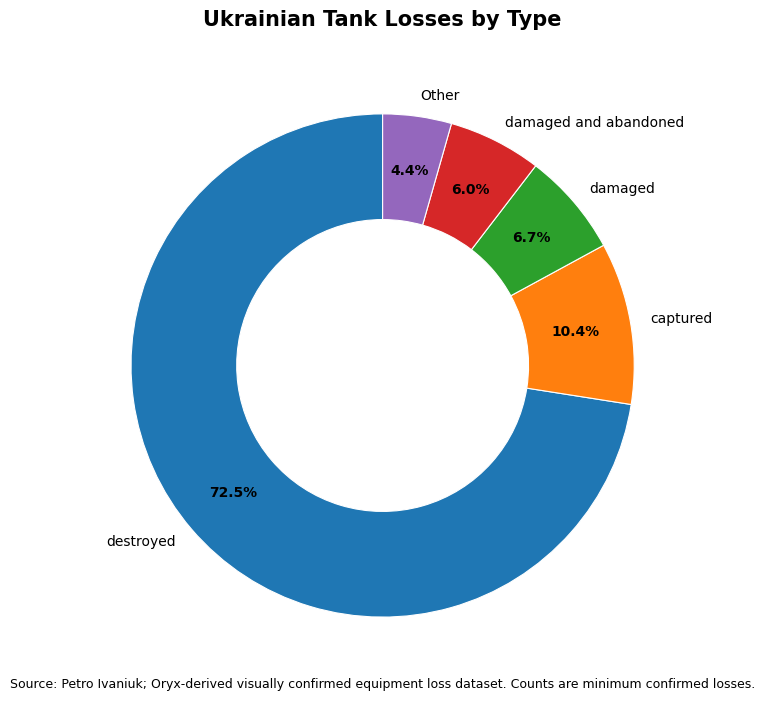

In [22]:
rus_loss_types = rus_tanks[rus_loss_cols].sum()
ukr_loss_types = ukr_tanks[ukr_loss_cols].sum()

rus_loss_types = rus_loss_types[rus_loss_types > 0].sort_values(ascending=False)
ukr_loss_types = ukr_loss_types[ukr_loss_types > 0].sort_values(ascending=False)


def clean_loss_types(data, cutoff=0.03):
    """
    Combines tiny categories into 'Other'.
    cutoff=0.03 means categories under 3% become Other.
    """
    total = data.sum()
    large = data[data / total >= cutoff]
    small = data[data / total < cutoff]

    if small.sum() > 0:
        large["Other"] = small.sum()

    return large.sort_values(ascending=False)


def make_donut_chart(data, title):
    data = clean_loss_types(data, cutoff=0.03)

    plt.figure(figsize=(8, 7))

    wedges, texts, autotexts = plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.78,
        labeldistance=1.08,
        wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 0.8}
    )

    plt.title(title, fontsize=15, fontweight="bold", pad=18)

    for text in texts:
        text.set_fontsize(10)

    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")

    plt.figtext(
        0.5,
        0.01,
        "Source: Petro Ivaniuk; Oryx-derived visually confirmed equipment loss dataset. Counts are minimum confirmed losses.",
        ha="center",
        fontsize=9
    )

    plt.tight_layout()
    plt.show()


make_donut_chart(rus_loss_types, "Russian Tank Losses by Type")
make_donut_chart(ukr_loss_types, "Ukrainian Tank Losses by Type")



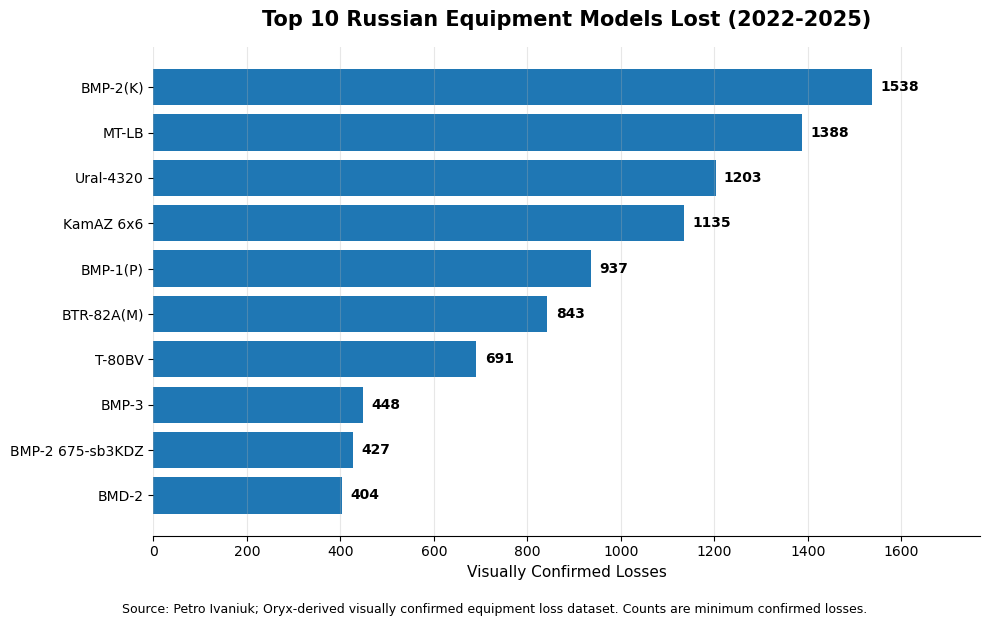

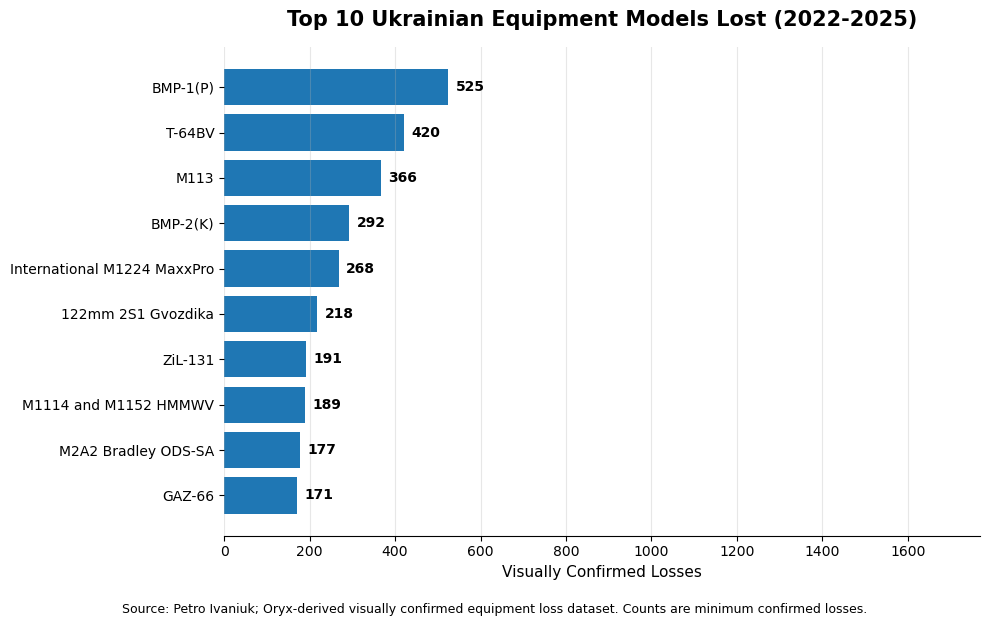

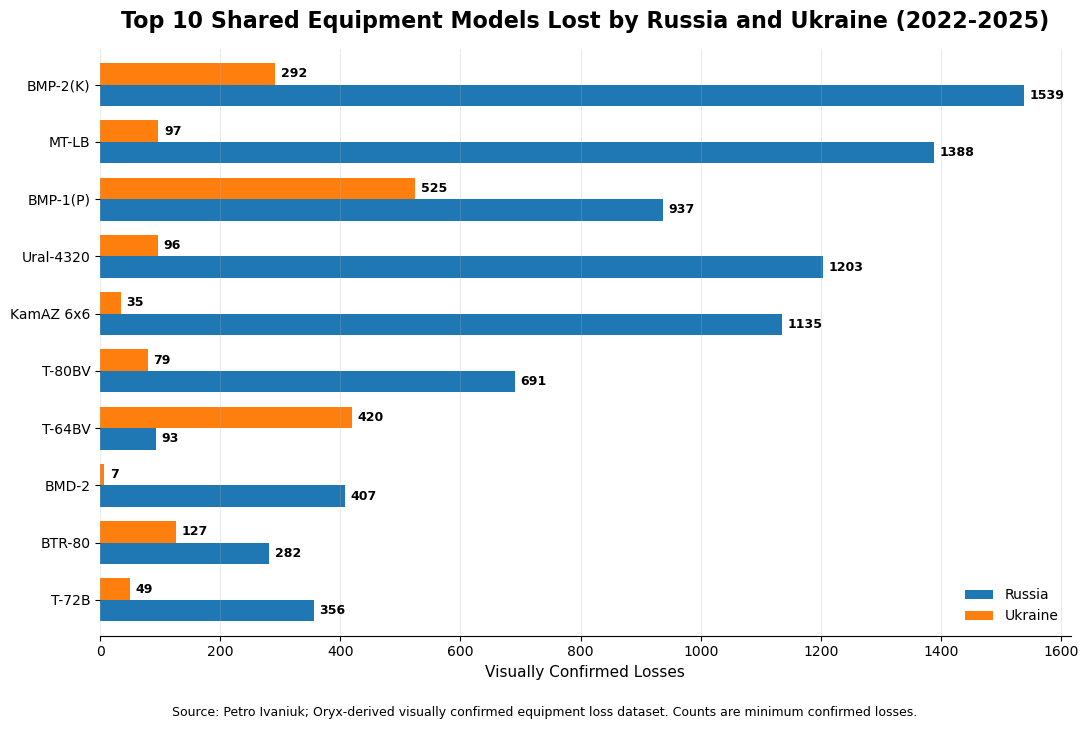

In [33]:
rus_known_models = rus[
    ~rus["model"].str.contains("unknown", case=False, na=False)
].copy()
ukr_known_models = ukr[
    ~ukr["model"].str.contains("unknown", case=False, na=False)
].copy()

top_rus_models = rus_known_models.sort_values("losses_total", ascending=False).head(10)
top_ukr_models = ukr_known_models.sort_values("losses_total", ascending=False).head(10)
rus_model_losses = rus_known_models.groupby("model")["losses_total"].sum()
ukr_model_losses = ukr_known_models.groupby("model")["losses_total"].sum()

max_loss = max(
    top_rus_models["losses_total"].max(),
    top_ukr_models["losses_total"].max()
)

x_limit = max_loss * 1.15


plt.figure(figsize=(10, 6))

bars = plt.barh(top_rus_models["model"], top_rus_models["losses_total"])

plt.title("Top 10 Russian Equipment Models Lost (2022-2025)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Visually Confirmed Losses", fontsize=11)
plt.ylabel("")

plt.xlim(0, x_limit)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (x_limit * 0.01),
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.figtext(
    0.5,
    -0.03,
    "Source: Petro Ivaniuk; Oryx-derived visually confirmed equipment loss dataset. Counts are minimum confirmed losses.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

bars = plt.barh(top_ukr_models["model"], top_ukr_models["losses_total"])

plt.title("Top 10 Ukrainian Equipment Models Lost (2022-2025)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Visually Confirmed Losses", fontsize=11)
plt.ylabel("")

plt.xlim(0, x_limit)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (x_limit * 0.01),
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.figtext(
    0.5,
    -0.03,
    "Source: Petro Ivaniuk; Oryx-derived visually confirmed equipment loss dataset. Counts are minimum confirmed losses.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

shared_models = pd.DataFrame({
    "Russia": rus_model_losses,
    "Ukraine": ukr_model_losses
}).fillna(0)

shared_models = shared_models[
    (shared_models["Russia"] > 0) &
    (shared_models["Ukraine"] > 0)
].copy()

shared_models["Combined Total"] = shared_models["Russia"] + shared_models["Ukraine"]
top_shared = shared_models.sort_values("Combined Total", ascending=False).head(10)

top_shared = top_shared.sort_values("Combined Total", ascending=True)

ax = top_shared[["Russia", "Ukraine"]].plot(
    kind="barh",
    figsize=(11, 7),
    width=0.75
)

ax.set_title(
    "Top 10 Shared Equipment Models Lost by Russia and Ukraine (2022-2025)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Visually Confirmed Losses", fontsize=11)
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues],
        padding=4,
        fontsize=9,
        fontweight="bold"
    )

ax.legend(title="", frameon=False, fontsize=10)

plt.figtext(
    0.5,
    -0.03,
    "Source: Petro Ivaniuk; Oryx-derived visually confirmed equipment loss dataset. Counts are minimum confirmed losses.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()




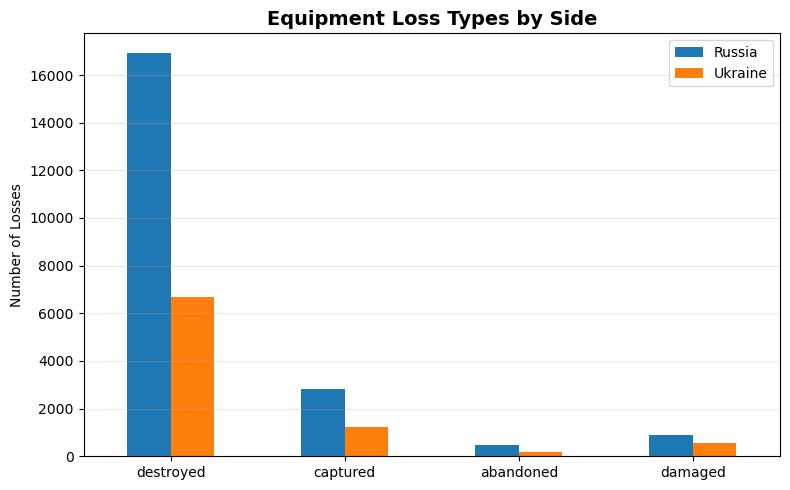

In [12]:
loss_types = ["destroyed", "captured", "abandoned", "damaged"]

rus_loss_summary = rus[loss_types].apply(pd.to_numeric, errors="coerce").fillna(0).sum()
ukr_loss_summary = ukr[loss_types].apply(pd.to_numeric, errors="coerce").fillna(0).sum()

loss_comparison = pd.DataFrame({
    "Russia": rus_loss_summary,
    "Ukraine": ukr_loss_summary
})

loss_comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Equipment Loss Types by Side", fontsize=14, fontweight="bold")
plt.ylabel("Number of Losses")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

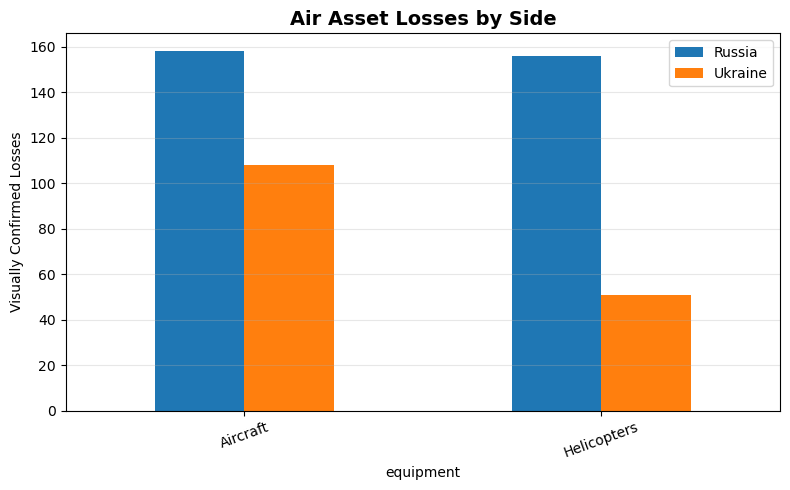

In [24]:
air_categories = ["Aircraft", "Helicopters", "Unmanned Aerial Vehicles"]

rus_air = rus[rus["equipment"].isin(air_categories)].groupby("equipment")["losses_total"].sum()
ukr_air = ukr[ukr["equipment"].isin(air_categories)].groupby("equipment")["losses_total"].sum()

air_comparison = pd.DataFrame({
    "Russia": rus_air,
    "Ukraine": ukr_air
}).fillna(0)

air_comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Air Asset Losses by Side", fontsize=14, fontweight="bold")
plt.ylabel("Visually Confirmed Losses")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()